# PSC Robustness Analysis

In [1]:
def default_params(): 
    return {
        'current_model': 'M1', 
        'quantization': 'none', #['none',"int4", "int8", "float32", "float16"]
        'dataset': {
            'path': '/workspaces/CodeSmells/semeru-datasets/code_smells/extraction',
            'transformation_list': ['curated','RenameVariable-1','RenameVariable-2','Add2Equal','SwitchEqualExp','InfixDividing', 'SwitchRelation'],
            'content_column': 'code',
            'sampling_size': 500,
        },
        'alignments_path': '/workspaces/CodeSmells/data/extension/alignments',

        'cache_dir': '/workspaces/CodeSmells/datax/hugging_face_cache',
    }
params = default_params()


#### Imports

In [2]:
import pandas as pd
import os
import time
import numpy as np
from datasets import load_dataset 
from statistics import mean, median
import json
import torch
import gc
import scipy.stats as stats

In [3]:
import seaborn as sns; sns.set_theme()
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.backends.backend_pdf import PdfPages

In [4]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import boxcox

#### Boostrapping

In [5]:
#| export
def bootstrapping( np_data, np_func, size ):
    """Create a bootstrap sample given data and a function
    For instance, a bootstrap sample of means, or mediands. 
    The bootstrap replicates are a long as the original size
    we can choose any observation more than once (resampling with replacement:np.random.choice)
    """
    
    #Cleaning NaNs
    #np_data_clean = np_data[ np.logical_not( np.isnan(np_data) ) ] 
    
    #The size of the bootstrap replicate is as big as size
    #Creating the boostrap replicates as long as the orignal data size
    #This strategy might work as imputation 
    bootstrap_repl = [ np_func( np.random.choice( np_data, size=len(np_data) ) ) for i in range( size ) ]
    
    #logging.info("Covariate: " + cov) #Empirical Mean
    #logging.info("Empirical Mean: " + str(np.mean(np_data_clean))) #Empirical Mean
    #logging.info("Bootstrapped Mean: " + str( np.mean(bootstrap_repl) ) ) #Bootstrapped Mean
    
    return np.array( bootstrap_repl )

#### Load Aggregates

In [6]:
def get_all_aggregates():
    aggregations = {}
    try:
        for transformation in params['dataset']['transformation_list']:
                transformation_df = pd.read_json(f"{params['alignments_path']}/{params['current_model']}_q_{params['quantization']}/{transformation}/aligned_smells.json")
                transformation_df['transformation'] = transformation
                aggregations[transformation] = transformation_df
        
        aggregations['base'] = aggregations.pop('curated')
    except Exception:
         None
    return aggregations


In [7]:
aggregations = get_all_aggregates()
aggregations.keys()

dict_keys(['curated', 'RenameVariable-1', 'RenameVariable-2', 'Add2Equal'])

In [8]:
alignments_df = aggregations['curated']
alignments_df['s_msg_id'].unique()

array(['W0311', 'C0301', 'C0303', 'C0415', 'W0212', 'W0612', 'C0114',
       'W0613', 'C0116', 'C0304', 'C0305', 'C0123', 'C0103', 'W0622',
       'C0209', 'W0511', 'C0321', 'C0200', 'R1705', 'R0914', 'R1735',
       'R0912', 'W1514', 'C2801', 'R1710', 'C0325', 'W0621', 'R1720',
       'R1732', 'W0611', 'W0719', 'W0104', 'W0707', 'W0718', 'R0917',
       'R0913', 'W0102', 'W1309', 'W1406', 'C3001', 'W0601'], dtype=object)

#### Distribution comparisson between transformations

In [9]:
## variability (std)
#alignments_df.groupby('s_msg_id')['code_smell_actual_prob_median'].describe()

In [10]:
# 3. Define the logit transform
def logit_transform(x, eps=1e-9):
    x_clipped = np.clip(x, eps, 1 - eps)
    return np.log(x_clipped / (1 - x_clipped))

In [11]:
def logit_transform_psc(smell_msg_id, prob_column, decimal_spaces, aggregations):
    filtered_aggregations = {}
    for aggregation_name, aggregation_df in aggregations.items():
        filtered_df = aggregation_df[aggregation_df['s_msg_id'] == smell_msg_id].copy()
        ## outliers removal
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = filtered_df[prob_column].quantile(0.25)
        Q3 = filtered_df[prob_column].quantile(0.75)

        # Compute the Interquartile Range (IQR)
        IQR = Q3 - Q1

        # Define lower and upper bounds for outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter out the outliers
        filtered_df = filtered_df[(filtered_df[prob_column] >= lower_bound) & 
              (filtered_df[prob_column] <= upper_bound)]
        #round
        filtered_df[prob_column] = filtered_df[prob_column].round(decimal_spaces)

        filtered_df[prob_column+'_trans'] = logit_transform(filtered_df[prob_column])
        filtered_aggregations[aggregation_name] = filtered_df
    return filtered_aggregations

In [12]:
def plot_density_distributions(smell_msg_id, psc_column, filtered_aggregations):
    combined_aggregates = pd.concat(filtered_aggregations.values(), ignore_index=True)
    # Plot histogram of actual data
    plt.figure(figsize=(10, 6))
    # Plot without the extra label parameter
    ax = sns.histplot(x=psc_column, 
                  data=combined_aggregates, 
                  hue='transformation', 
                  kde=True, 
                  bins=250, 
                  stat="density")

    # Add labels and title
    plt.title("Distribution by Transformation")
    plt.xlabel("PSC Column")

    # Show the plot
    plt.show()


In [13]:
alignments_df['s_msg_id'].unique()

array(['W0311', 'C0301', 'C0303', 'C0415', 'W0212', 'W0612', 'C0114',
       'W0613', 'C0116', 'C0304', 'C0305', 'C0123', 'C0103', 'W0622',
       'C0209', 'W0511', 'C0321', 'C0200', 'R1705', 'R0914', 'R1735',
       'R0912', 'W1514', 'C2801', 'R1710', 'C0325', 'W0621', 'R1720',
       'R1732', 'W0611', 'W0719', 'W0104', 'W0707', 'W0718', 'R0917',
       'R0913', 'W0102', 'W1309', 'W1406', 'C3001', 'W0601'], dtype=object)

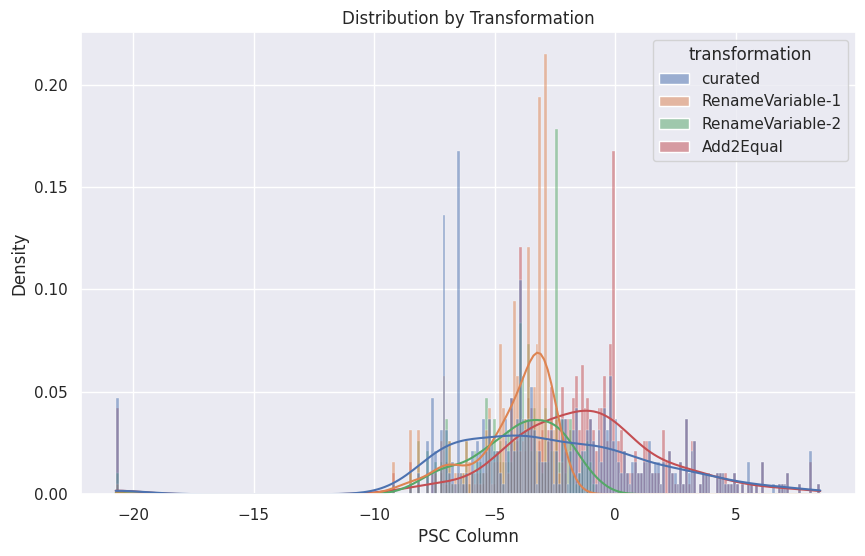

In [14]:
##probability distributions per type of smell
smell_msg_id = 'C0103'
prob_column = 'code_smell_actual_prob_median'
filtered_aggregations = logit_transform_psc(smell_msg_id, prob_column, 4, aggregations)
plot_density_distributions(smell_msg_id, prob_column+'_trans', filtered_aggregations)